In [1]:
# Stage 2 — Setup and Reproducible Environment

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

In [2]:
# Load the course dataset
df = pd.read_csv("delivery_times.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (600, 5)


,distance_km,prep_time_min,traffic_level,rain,delivery_min
0,9.40,17,1,0,51.3
1,5.55,24,2,1,54.2
2,10.37,28,3,0,67.7
3,8.52,23,2,0,51.2
4,1.58,29,2,1,42.1


In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDataset information:")
df.info()

Columns:
['distance_km', 'prep_time_min', 'traffic_level', 'rain', 'delivery_min']

Missing values:
distance_km      0
prep_time_min    0
traffic_level    0
rain             0
delivery_min     0
dtype: int64

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   distance_km    600 non-null    float64
 1   prep_time_min  600 non-null    int64  
 2   traffic_level  600 non-null    int64  
 3   rain           600 non-null    int64  
 4   delivery_min   600 non-null    float64
dtypes: float64(2), int64(3)
memory usage: 23.6 KB


In [4]:
display(df.describe(include="all"))

,distance_km,prep_time_min,traffic_level,rain,delivery_min
count,600.000000,600.000000,600.000000,600.000000,600.000000
mean,6.203850,17.590000,2.003333,0.261667,46.609167
std,3.303183,7.415539,0.804820,0.439909,12.063613
min,0.560000,5.000000,1.000000,0.000000,18.500000
25%,3.220000,11.000000,1.000000,0.000000,37.800000
50%,6.250000,17.000000,2.000000,0.000000,46.500000
75%,9.130000,24.000000,3.000000,1.000000,55.675000
max,11.990000,30.000000,3.000000,1.000000,75.100000


In [5]:
# Stage 3 — First Honest Prediction

X = df.drop("delivery_min", axis=1)
y = df["delivery_min"]

print("Features:")
display(X.head())

print("Target:")
display(y.head())

Features:


,distance_km,prep_time_min,traffic_level,rain
0,9.40,17,1,0
1,5.55,24,2,1
2,10.37,28,3,0
3,8.52,23,2,0
4,1.58,29,2,1


Target:


,delivery_min
0,51.3
1,54.2
2,67.7
3,51.2
4,42.1


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 480
Testing samples: 120


In [7]:
numeric_features = ["distance_km", "prep_time_min", "rain"]
categorical_features = ["traffic_level"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [8]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

In [9]:
linear_mae = mean_absolute_error(y_test, linear_predictions)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_predictions)
)

print("Linear Regression")
print("-----------------")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)

Linear Regression
-----------------
MAE : 1.921452519124137
RMSE: 2.479578133850648


In [10]:
# Always-guess-the-training-average baseline

baseline_prediction = y_train.mean()

baseline_predictions = np.full(
    len(y_test),
    baseline_prediction
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

print("Baseline average prediction:", baseline_prediction)
print("Baseline MAE:", baseline_mae)

Baseline average prediction: 47.05958333333333
Baseline MAE: 10.318104166666666


In [11]:
knn_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", KNeighborsRegressor(n_neighbors=5))
    ]
)

knn_model.fit(X_train, y_train)

knn_predictions = knn_model.predict(X_test)

knn_mae = mean_absolute_error(y_test, knn_predictions)
knn_rmse = np.sqrt(mean_squared_error(y_test, knn_predictions))

print("kNN")
print("MAE :", knn_mae)
print("RMSE:", knn_rmse)

kNN
MAE : 2.561166666666667
RMSE: 3.287008264871468


In [12]:
tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            max_depth=8,
            random_state=42
        ))
    ]
)

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

tree_mae = mean_absolute_error(y_test, tree_predictions)
tree_rmse = np.sqrt(mean_squared_error(y_test, tree_predictions))

print("Decision Tree")
print("MAE :", tree_mae)
print("RMSE:", tree_rmse)

Decision Tree
MAE : 3.242770442520442
RMSE: 4.198091002402812


In [13]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42
        ))
    ]
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

print("Random Forest")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)

Random Forest
MAE : 2.4456666666666678
RMSE: 3.0977304810672823


In [14]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "kNN",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        knn_mae,
        tree_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        knn_rmse,
        tree_rmse,
        rf_rmse
    ]
})

comparison = comparison.sort_values("MAE").reset_index(drop=True)

display(comparison)

,Model,MAE,RMSE
0,Linear Regression,1.921453,2.479578
1,Random Forest,2.445667,3.097730
2,kNN,2.561167,3.287008
3,Decision Tree,3.242770,4.198091


In [15]:
best_model = comparison.loc[
    comparison["MAE"].idxmin(),
    "Model"
]

best_mae = comparison["MAE"].min()

print("Best model:", best_model)
print("Best MAE:", best_mae)

Best model: Linear Regression
Best MAE: 1.921452519124137


In [16]:
from sklearn.model_selection import RandomizedSearchCV

In [17]:
# Stage 5 — Automated Model Search

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            random_state=42
        ))
    ]
)

param_grid = {
    "model__n_estimators": [50, 100, 150, 200],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None]
}

In [19]:
automl_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=5,
    random_state=42,
    n_jobs=-1
)

automl_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['distance_km',
                                                                                'prep_time_min',
                                                                                'rain']),
                                                                              ('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['traffic_level'])])),
                                             ('model',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__max_depth': [None, 5, 10, 15,
                                                             20],
                                        'model__max_features': ['sqrt', 'log2',
                                                                None],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [50, 100, 150,
                                                                200]},
                   random_state=42, scoring='neg_mean_absolute_error')

In [20]:
print("Best parameters:")
print(automl_search.best_params_)

Best parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 20}


In [21]:
best_cv_mae = -automl_search.best_score_

print("Best cross-validation MAE:", best_cv_mae)

Best cross-validation MAE: 2.657423263888887


In [22]:
automl_predictions = automl_search.predict(X_test)

automl_mae = mean_absolute_error(
    y_test,
    automl_predictions
)

automl_rmse = np.sqrt(
    mean_squared_error(y_test, automl_predictions)
)

print("AutoML/Search Model")
print("-------------------")
print("Test MAE :", automl_mae)
print("Test RMSE:", automl_rmse)

AutoML/Search Model
-------------------
Test MAE : 2.490158333333334
Test RMSE: 3.21505530149431


In [23]:
comparison_automl = pd.concat([
    comparison,
    pd.DataFrame({
        "Model": ["AutoML Random Forest"],
        "MAE": [automl_mae],
        "RMSE": [automl_rmse]
    })
], ignore_index=True)

comparison_automl = comparison_automl.sort_values(
    "MAE"
).reset_index(drop=True)

display(comparison_automl)

,Model,MAE,RMSE
0,Linear Regression,1.921453,2.479578
1,Random Forest,2.445667,3.097730
2,AutoML Random Forest,2.490158,3.215055
3,kNN,2.561167,3.287008
4,Decision Tree,3.242770,4.198091


In [24]:
automl_settings = {
    "Tool": "scikit-learn RandomizedSearchCV",
    "Search space": "Random Forest hyperparameters",
    "Metric": "MAE",
    "CV": 5,
    "Number of random configurations": 20,
    "Random state": 42,
    "Model budget": "20 configurations × 5-fold CV"
}

for key, value in automl_settings.items():
    print(f"{key}: {value}")

Tool: scikit-learn RandomizedSearchCV
Search space: Random Forest hyperparameters
Metric: MAE
CV: 5
Number of random configurations: 20
Random state: 42
Model budget: 20 configurations × 5-fold CV


### AutoML Interpretation

RandomizedSearchCV automated the process of selecting and evaluating different Random Forest
hyperparameter combinations using cross-validation.

I still decided the dataset, train/test split, target metric (MAE), search space, number of
configurations, cross-validation strategy, and random_state.

The AutoML/search result can then be compared with the manually configured models using the
unseen test set.

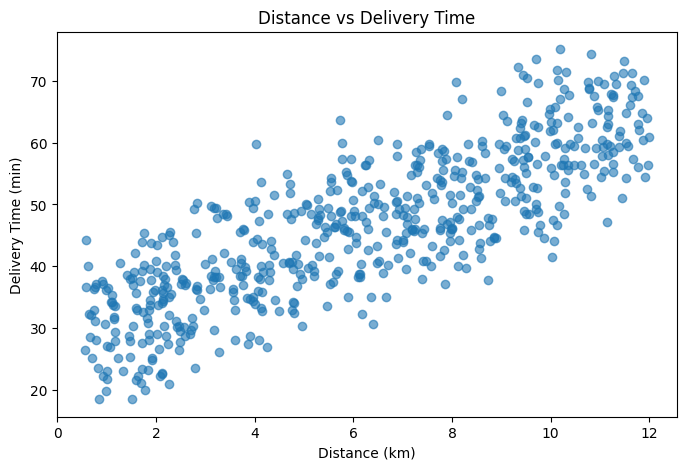

In [25]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["distance_km"],
    df["delivery_min"],
    alpha=0.6
)

plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (min)")
plt.title("Distance vs Delivery Time")

plt.show()

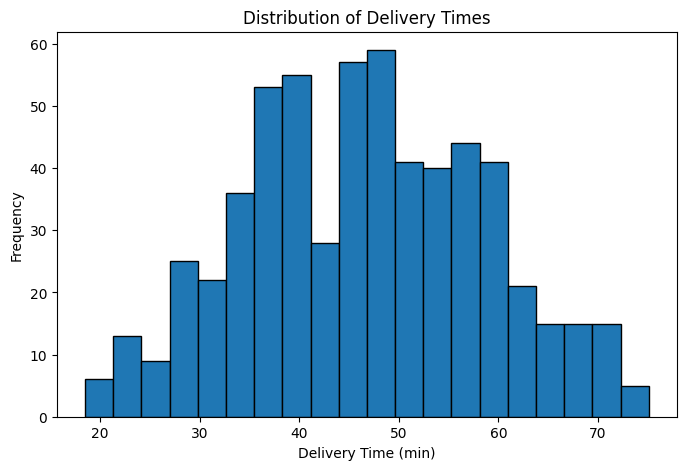

In [26]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["delivery_min"],
    bins=20,
    edgecolor="black"
)

plt.xlabel("Delivery Time (min)")
plt.ylabel("Frequency")
plt.title("Distribution of Delivery Times")

plt.show()

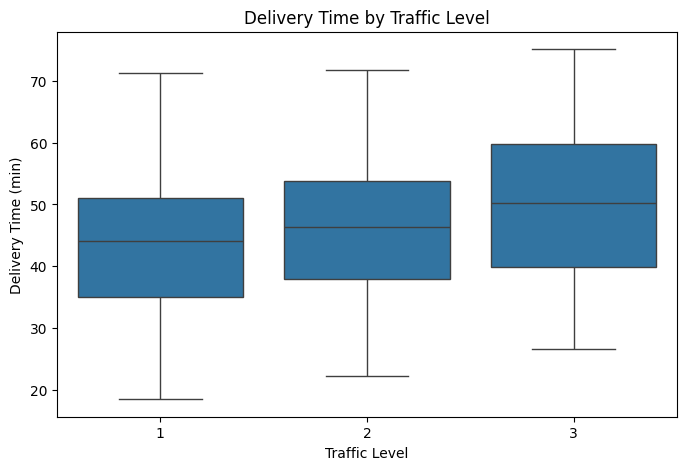

In [27]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="traffic_level",
    y="delivery_min"
)

plt.xlabel("Traffic Level")
plt.ylabel("Delivery Time (min)")
plt.title("Delivery Time by Traffic Level")

plt.show()

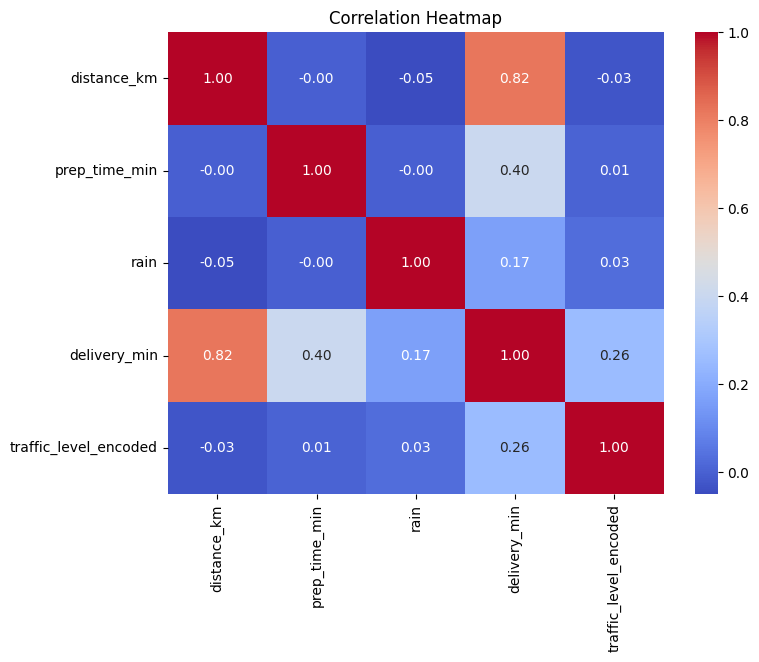

In [28]:
correlation_df = df.copy()

correlation_df["traffic_level_encoded"] = (
    correlation_df["traffic_level"]
    .astype("category")
    .cat.codes
)

correlation_df = correlation_df.drop(
    "traffic_level",
    axis=1
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

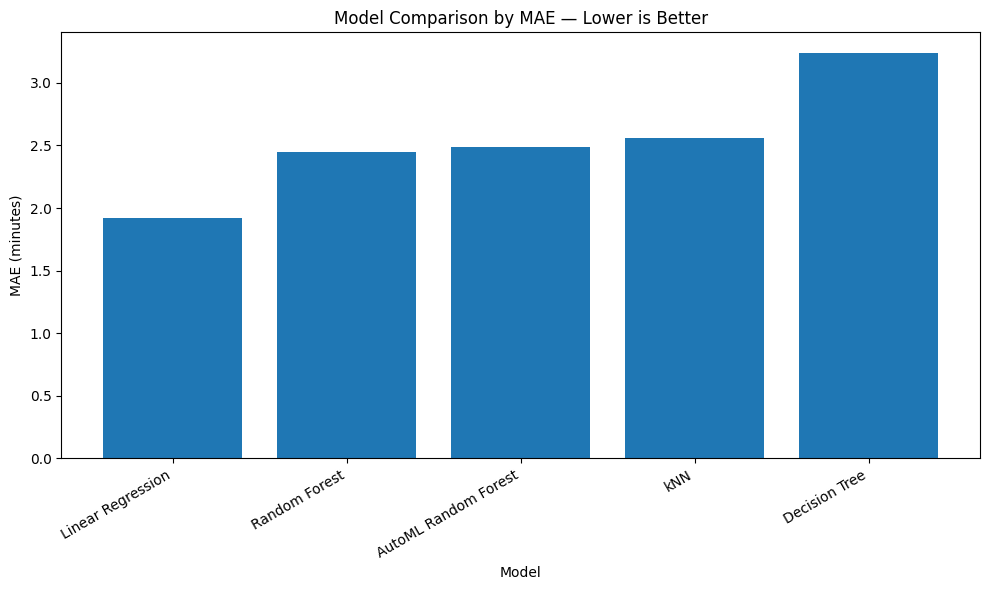

In [29]:
mae_comparison = comparison_automl.sort_values(
    "MAE",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.bar(
    mae_comparison["Model"],
    mae_comparison["MAE"]
)

plt.xlabel("Model")
plt.ylabel("MAE (minutes)")
plt.title("Model Comparison by MAE — Lower is Better")

plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

In [30]:
comparison_automl.to_csv(
    "model_comparison.csv",
    index=False
)

print("Saved: model_comparison.csv")

Saved: model_comparison.csv


## Visualization Interpretation

### Model MAE Comparison

The model MAE bar chart provides an easy way for a non-technical reader to compare prediction
accuracy. MAE represents the average number of minutes by which a model's prediction differs
from the actual delivery time.

Therefore, a shorter bar means the model makes smaller average prediction errors. The chart
makes it immediately clear which model provides the most accurate delivery-time predictions
without requiring the reader to understand the internal mathematics of each algorithm.

# Conclusions

1. The project predicts food delivery time using distance, preparation time, traffic level and rain.
2. A simple average-prediction baseline was established before evaluating machine-learning models.
3. Linear Regression, kNN, Decision Tree and Random Forest were trained using the same train/test split.
4. MAE and RMSE were used to objectively compare model performance.
5. Automated hyperparameter search was performed using RandomizedSearchCV.
6. The AutoML/search result was evaluated on the same unseen test set and compared with manually configured models.
7. Visualizations were created to communicate relationships in the data and differences in model performance.
8. The workflow follows a reproducible MLOps process:

Data → Features → Train → Evaluate → Compare → Search → Visualize

# Reproducibility Record

| Item | Value |
|---|---|
| Dataset | `data/delivery_times.csv` |
| Target | `delivery_min` |
| Test size | 20% |
| Random state | 42 |
| Models | Linear Regression, kNN, Decision Tree, Random Forest |
| Evaluation metrics | MAE, RMSE |
| AutoML/Search tool | scikit-learn RandomizedSearchCV |
| AutoML iterations | 20 |
| Cross-validation | 5-fold |
| Search metric | Negative MAE |
| Visualization output | PNG/Notebook plots |
| Model comparison output | `model_comparison.csv` |

## Workflow

Data → Features → Train → Evaluate → Compare → Search → Visualize